Download necessary libraries

In [1]:
!pip install tensorflow pandas numpy scikit-learn matplotlib seaborn opencv-python pillow albumentations kaggle


In [2]:
import pandas as pd
df = pd.read_csv("/content/cleaned_flipkart_data (1).csv", engine='python')
# Get a random sample of 1000 entries
df = df.sample(n=1000, random_state=42) # Using random_state for reproducibility
df.head()
df.columns.tolist()

['uniq_id',
 'product_url',
 'product_name',
 'product_category_tree',
 'pid',
 'retail_price',
 'discounted_price',
 'image',
 'is_FK_Advantage_product',
 'description',
 'product_rating',
 'overall_rating',
 'product_specifications',
 'crawl_date',
 'crawl_time',
 'main_category']

In [3]:
df['product_category_tree'].nunique(), df['product_category_tree'].value_counts().head()

(495,
 product_category_tree
 ["Jewellery >> Rings"]                                                                                63
 ["Automotive >> Accessories & Spare parts >> Car Interior & Exterior >> Car Interior >> Car Mats"]    63
 ["Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Bras >> S4S Bras"]                    43
 ["Footwear >> Women's Footwear >> Casual Shoes >> Boots"]                                             31
 ["Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Bras >> Grafion Bras"]                23
 Name: count, dtype: int64)

In [4]:
# missing labels / duplicate ids / URL check
df['product_category_tree'].isna().sum()
df['image'].isna().sum()   # replace 'image' with actual column name
# counts
vc = df['product_category_tree'].value_counts()
vc.tail(20)   # rare classes


,count
product_category_tree,
"[""Mobiles & Accessories >> Mobile Accessories >> Speakers >> Shortkut enterprises Speakers >> Shortkut enterprises Model no 476 Mobile/Tablet ...""]",1
"[""Clothing >> Women's Clothing >> Western Wear >> Leggings & Jeggings >> Leggings & Jeggings >> medha Leggings & Jeggings >> medha Women's Multicolor Leggings (Pack of 5)""]",1
"[""Clothing >> Men's Clothing >> Sports Wear >> Track Pants >> TAMBAS Track Pants >> TAMBAS Solid Men's Track Pants""]",1
"[""Kitchen & Dining >> Coffee Mugs >> AKUP Coffee Mugs >> AKUP i-creid-because Ceramic Mug (300 ml)""]",1
"[""Watches >> Wrist Watches >> TAG Heuer Wrist Watches""]",1
"[""Clothing >> Women's Clothing >> Western Wear >> Shirts, Tops & Tunics >> Tops >> Riot Jeans Tops >> Riot Jeans Casual Sleeveless Printed Women's Top""]",1
"[""Sports & Fitness >> Fitness Accessories >> Bottles & Shakers >> Tuelip Bottles & Shakers >> Tuelip Silver Sipper Bottle 600 ml Sipper (Pack ...""]",1
"[""Clothing >> Women's Clothing >> Winter & Seasonal Wear >> Coats >> Only Coats >> Only Women's Double Breasted""]",1
"[""Sunglasses >> AAO+ Aviator Sunglasses""]",1


In [5]:
# Split hierarchical category
df['tags_list'] = df['product_category_tree'].fillna('').apply(lambda x: [t.strip() for t in x.split('>>')])

# Build global tag vocabulary
all_tags = sorted(set(tag for tags in df['tags_list'] for tag in tags))
tag_to_idx = {tag: i for i, tag in enumerate(all_tags)}
df['tags_list']

,tags_list
3188,"[[""Clothing, Women's Clothing, Western Wear, J..."
764,"[[""Clothing, Kids' Clothing, Girls Wear, T-Shi..."
3264,"[[""Pens & Stationery, College Supplies, SHOPMA..."
1967,"[[""Home Decor & Festive Needs, Showpieces, Exo..."
2185,"[[""Clothing, Women's Clothing, Lingerie, Sleep..."
...,...
290,"[[""Footwear, Women's Footwear, Casual Shoes, B..."
1106,"[[""Clothing, Women's Clothing, Western Wear, L..."
1419,"[[""Clothing, Men's Clothing, Sports Wear, Trac..."
866,"[[""Clothing, Women's Clothing, Western Wear, S..."


In [6]:
import numpy as np

def encode_tags(tag_list):
    vec = np.zeros(len(all_tags), dtype=np.float32)
    for tag in tag_list:
        vec[tag_to_idx[tag]] = 1
    return vec

df['tags_vector'] = df['tags_list'].apply(encode_tags)
display(df['tags_vector'])

,tags_vector
3188,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
764,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3264,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1967,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2185,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...
290,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1106,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1419,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
866,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [7]:
df['image'].head(10).tolist()


['["http://img5a.flixcart.com/image/jean/g/p/z/abrolsons-10004-blue-timberlake-l-1000x1000-imaeg887efjz7mnd.jpeg", "http://img5a.flixcart.com/image/jean/g/p/z/abrolsons-10004-blue-timberlake-l-original-imaeg887efjz7mnd.jpeg", "http://img6a.flixcart.com/image/jean/g/p/z/abrolsons-10004-blue-timberlake-l-original-imaeg8878ykcqdnf.jpeg", "http://img5a.flixcart.com/image/jean/g/p/z/abrolsons-10004-blue-timberlake-l-original-imaeg8878djgp4pa.jpeg", "http://img5a.flixcart.com/image/jean/g/p/z/abrolsons-10004-blue-timberlake-l-original-imaeg8873xngzvbr.jpeg"]',
 '["http://img5a.flixcart.com/image/top/5/v/s/18-12-zmlj-001-002-ml1-my-little-joy-12-18-months-original-imaeb88zcn9f8z3j.jpeg", "http://img6a.flixcart.com/image/top/f/k/x/96-84-zmlj-001-004-ml6-my-little-joy-7-8-years-original-imaea22u6cjggjvz.jpeg", "http://img5a.flixcart.com/image/top/f/k/x/48-36-zmlj-001-004-ml6-my-little-joy-3-4-years-original-imaea22utkn7svkc.jpeg", "http://img5a.flixcart.com/image/top/k/g/r/24-18-zmlj-002-004-ml

In [8]:
valid_rows = []
for u in df['image'].head(50):   # check first 50
    try:
        r = requests.get(u, timeout=5)
        print(u, r.status_code, r.headers.get('Content-Type'))
    except Exception as e:
        print(u, "FAILED", e)


["http://img5a.flixcart.com/image/jean/g/p/z/abrolsons-10004-blue-timberlake-l-1000x1000-imaeg887efjz7mnd.jpeg", "http://img5a.flixcart.com/image/jean/g/p/z/abrolsons-10004-blue-timberlake-l-original-imaeg887efjz7mnd.jpeg", "http://img6a.flixcart.com/image/jean/g/p/z/abrolsons-10004-blue-timberlake-l-original-imaeg8878ykcqdnf.jpeg", "http://img5a.flixcart.com/image/jean/g/p/z/abrolsons-10004-blue-timberlake-l-original-imaeg8878djgp4pa.jpeg", "http://img5a.flixcart.com/image/jean/g/p/z/abrolsons-10004-blue-timberlake-l-original-imaeg8873xngzvbr.jpeg"] FAILED name 'requests' is not defined
["http://img5a.flixcart.com/image/top/5/v/s/18-12-zmlj-001-002-ml1-my-little-joy-12-18-months-original-imaeb88zcn9f8z3j.jpeg", "http://img6a.flixcart.com/image/top/f/k/x/96-84-zmlj-001-004-ml6-my-little-joy-7-8-years-original-imaea22u6cjggjvz.jpeg", "http://img5a.flixcart.com/image/top/f/k/x/48-36-zmlj-001-004-ml6-my-little-joy-3-4-years-original-imaea22utkn7svkc.jpeg", "http://img5a.flixcart.com/image

In [9]:
import ast

def extract_first_url(cell):
    try:
        url_list = ast.literal_eval(cell)
        if isinstance(url_list, list) and len(url_list) > 0:
            return url_list[0]
    except:
        return None
    return None

df['first_image_url'] = df['image'].apply(extract_first_url)
df = df.dropna(subset=['first_image_url'])
df['first_image_url'].head()


,first_image_url
3188,http://img5a.flixcart.com/image/jean/g/p/z/abr...
764,http://img5a.flixcart.com/image/top/5/v/s/18-1...
3264,http://img5a.flixcart.com/image/diary-notebook...
1967,http://img5a.flixcart.com/image/showpiece-figu...
2185,http://img6a.flixcart.com/image/bra/2/z/f/pihu...


In [10]:
import os
import requests
import hashlib
from concurrent.futures import ThreadPoolExecutor

os.makedirs("images", exist_ok=True)

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36"
}

def download_one(url):
    try:
        if not isinstance(url, str) or not url.startswith("http"):
            return None

        r = requests.get(url, headers=HEADERS, timeout=10)
        if r.status_code == 200 and r.headers.get('Content-Type', '').startswith('image'):
            filename = hashlib.md5(r.content).hexdigest() + ".jpg"
            path = os.path.join("images", filename)
            if not os.path.exists(path):
                with open(path, 'wb') as f:
                    f.write(r.content)
            return path
        else:
            return None
    except Exception as e:
        return None

with ThreadPoolExecutor(max_workers=12) as executor:
    image_paths = list(executor.map(download_one, df['first_image_url']))

df['image_path'] = image_paths
df = df.dropna(subset=['image_path']).reset_index(drop=True)

print(f"✅ Successfully downloaded {df.shape[0]} images.")


✅ Successfully downloaded 897 images.


In [11]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
import numpy as np

X = df['image_path'].values
y = np.stack(df['tags_vector'].values)

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Filter out invalid image paths
def is_valid_image(path):
    try:
        img = tf.io.read_file(path)
        tf.image.decode_image(img, channels=3) # Use decode_image to support multiple formats
        return True
    except:
        return False

train_indices = [i for i, path in enumerate(X_train) if is_valid_image(path)]
val_indices = [i for i, path in enumerate(X_val) if is_valid_image(path)]

X_train_filtered = X_train[train_indices]
y_train_filtered = y_train[train_indices]
X_val_filtered = X_val[val_indices]
y_val_filtered = y_val[val_indices]

print(f"Filtered training set: {len(X_train_filtered)} images")
print(f"Filtered validation set: {len(X_val_filtered)} images")

Filtered training set: 703 images
Filtered validation set: 179 images


In [13]:
import tensorflow as tf
from tensorflow.keras.applications.resnet_v2 import preprocess_input

IMG_SIZE = 224

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = preprocess_input(img)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train_filtered, y_train_filtered))
train_ds = train_ds.shuffle(10000).map(load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val_filtered, y_val_filtered))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

In [14]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg_preprocess

vgg_base = VGG19(weights='imagenet', include_top=True, input_shape=(224,224,3))
feature_model = Model(inputs=vgg_base.input, outputs=vgg_base.get_layer('fc2').output)


574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step


In [15]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models

num_tags = len(all_tags)
base = ResNet50V2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
base.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)
x = layers.Dropout(0.4)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_tags, activation='sigmoid')(x)   # Multi-label output
model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.Precision(thresholds=0.5),
        tf.keras.metrics.Recall(thresholds=0.5)
    ]
)

model.summary()


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 2048)           │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 955)            │       489,915 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,103,803 (95.76 MB)

 Trainable params: 1,539,003 (5.87 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('autotag_model.keras', save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)


Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 167s 7s/step - loss: 0.3407 - precision: 0.0068 - recall: 0.2132 - val_loss: 0.0398 - val_precision: 0.9333 - val_recall: 0.1617
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 148s 7s/step - loss: 0.0381 - precision: 0.5142 - recall: 0.2371 - val_loss: 0.0276 - val_precision: 0.9219 - val_recall: 0.3184
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 133s 6s/step - loss: 0.0243 - precision: 0.7561 - recall: 0.3507 - val_loss: 0.0191 - val_precision: 0.8832 - val_recall: 0.3979
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 139s 6s/step - loss: 0.0170 - precision: 0.8608 - recall: 0.4215 - val_loss: 0.0171 - val_precision: 0.8987 - val_recall: 0.4326
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 151s 7s/step - loss: 0.0143 - precision: 0.8803 - recall: 0.4652 - val_loss: 0.0160 - val_precision: 0.9064 - val_recall: 0.4724


In [17]:
base.trainable = True
for layer in base.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Precision(thresholds=0.5), tf.keras.metrics.Recall(thresholds=0.5)]
)

model.fit(train_ds, validation_data=val_ds, epochs=3, callbacks=callbacks)


Epoch 1/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 236s 10s/step - loss: 0.0193 - precision_1: 0.9095 - recall_1: 0.3113 - val_loss: 0.0159 - val_precision_1: 0.9171 - val_recall_1: 0.4685
Epoch 2/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 210s 10s/step - loss: 0.0163 - precision_1: 0.9204 - recall_1: 0.3477 - val_loss: 0.0159 - val_precision_1: 0.9160 - val_recall_1: 0.4621
Epoch 3/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 258s 9s/step - loss: 0.0154 - precision_1: 0.9515 - recall_1: 0.3584 - val_loss: 0.0159 - val_precision_1: 0.9160 - val_recall_1: 0.4621


In [19]:
# Build parent-child mapping
from collections import defaultdict

parent_of = {}
for tags in df['tags_list']:
    for i in range(1, len(tags)):
        parent_of[tags[i]] = tags[i-1]

def add_parents(pred_tags):
    result = set(pred_tags)
    for tag in list(pred_tags):
        p = parent_of.get(tag)
        while p:
            result.add(p)
            p = parent_of.get(p)
    return list(result)


In [20]:
df['tags_list'] = df['product_category_tree'].apply(lambda x: [t.strip() for t in x.split('>>')])


In [21]:
def predict_tags(image_path, threshold=0.5):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    x = preprocess_input(tf.expand_dims(img, 0))
    probs = model.predict(x)[0]
    idx = np.where(probs >= threshold)[0]
    tags = [all_tags[i] for i in idx]
    return add_parents(tags)

# Example: Predict tags for the first downloaded image
if not df.empty:
    first_image_path = df['image_path'].iloc[0]
    predicted_tags = predict_tags(first_image_path)
    print(f"Predicted tags for {first_image_path}: {predicted_tags}")
else:
    print("No images available in the DataFrame to make a prediction.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted tags for images/5c7434b7281bcf809237b5f380625692.jpg: ['["Clothing', 'Shirts, Tops & Tunics', "Women's Clothing", 'Western Wear', 'Tops']


In [22]:
import IPython.display as display
from PIL import Image
import os
import numpy as np
import random

def predict_and_show_random(threshold=0.5):
    # 0. Pick a random image from the DataFrame
    if df.empty:
        print("❌ No images available in the DataFrame.")
        return None, None

    random_row = df.sample(1).iloc[0]
    image_path = random_row['image_path']

    # 1. Predict tags
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    x = preprocess_input(tf.expand_dims(img, 0))
    probs = model.predict(x)[0]

    idx = np.where(probs >= threshold)[0]
    pred_tags = [all_tags[i] for i in idx]
    pred_tags = add_parents(pred_tags)

    # 2. Actual tags
    actual_tags = random_row['tags_list']

    # 3. Display the image inline
    pil_img = Image.open(image_path)
    display.display(pil_img)

    # 4. Clickable file link
    file_link = f"file://{os.path.abspath(image_path)}"
    display.display(display.HTML(f"<a href='{file_link}' target='_blank'>Open Image File</a>"))

    # 5. Print comparison
    print(f"🖼️ Image Path: {image_path}")
    print("✅ Predicted tags:", pred_tags)
    print("🎯 Actual tags:", actual_tags)

    # 6. Correct / Missed / Extra
    correct = set(pred_tags) & set(actual_tags)
    missed = set(actual_tags) - set(pred_tags)
    extra = set(pred_tags) - set(actual_tags)

    print(f"🟢 Correct: {list(correct)}")
    print(f"🔸 Missed: {list(missed)}")
    print(f"🔺 Extra: {list(extra)}")

    return pred_tags, actual_tags


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


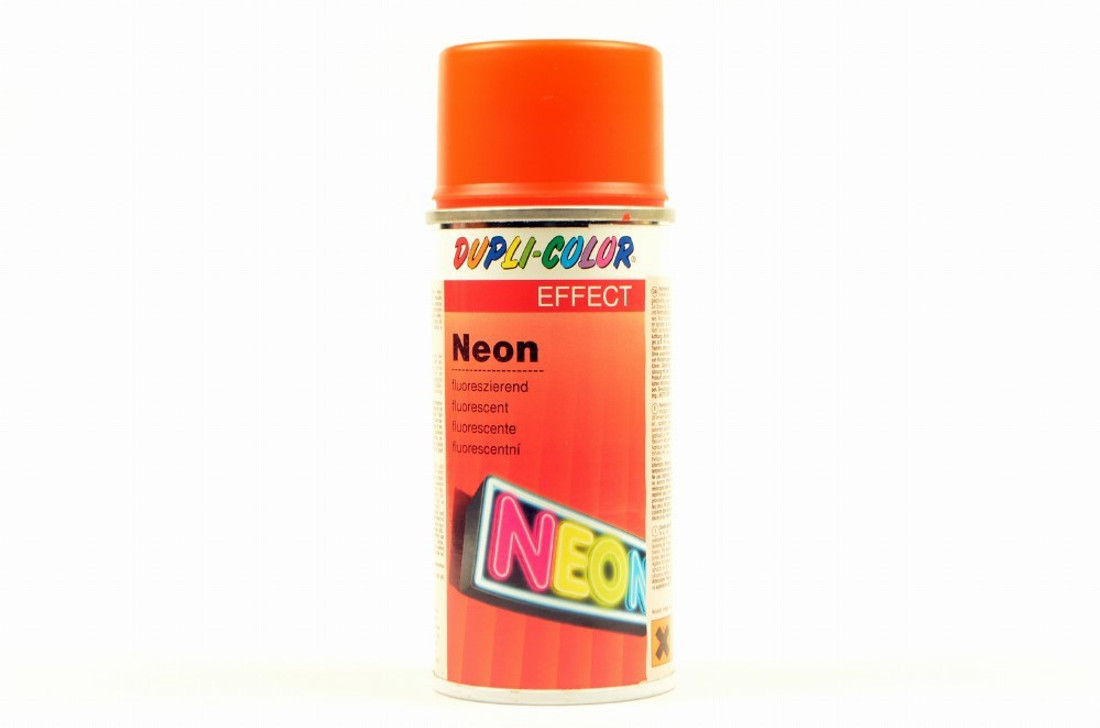

🖼️ Image Path: images/838602ca97bfdc90024691a40945bd64.jpg
✅ Predicted tags: []
🎯 Actual tags: ['["Toys & School Supplies', 'Dupli Color Toys & School Supplies', 'Dupli Color Spray Paint Bottle (Set of 1, Signal..."]']
🟢 Correct: []
🔸 Missed: ['Dupli Color Spray Paint Bottle (Set of 1, Signal..."]', 'Dupli Color Toys & School Supplies', '["Toys & School Supplies']
🔺 Extra: []


([],
 ['["Toys & School Supplies',
  'Dupli Color Toys & School Supplies',
  'Dupli Color Spray Paint Bottle (Set of 1, Signal..."]'])

In [24]:
# Run multiple times to get different random images each time
predict_and_show_random()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


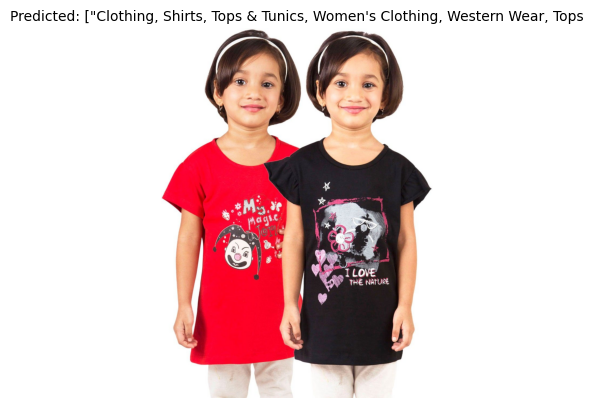

✅ Predicted tags: ['["Clothing', 'Shirts, Tops & Tunics', "Women's Clothing", 'Western Wear', 'Tops']


In [25]:
import matplotlib.pyplot as plt

def predict_and_plot(image_path, threshold=0.5):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    x = preprocess_input(tf.expand_dims(img, 0))
    probs = model.predict(x)[0]
    idx = np.where(probs >= threshold)[0]
    tags = [all_tags[i] for i in idx]
    tags = add_parents(tags)

    img_disp = plt.imread(image_path)
    plt.imshow(img_disp)
    plt.axis('off')
    plt.title(f"Predicted: {', '.join(tags)}", fontsize=10)
    plt.show()
    print(f"✅ Predicted tags: {tags}")
    return tags

if not df.empty:
    first_image_path = df['image_path'].iloc[0]
    predict_and_plot(first_image_path)


In [26]:
# Evaluate the model on the validation dataset
loss, precision, recall = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Precision: {precision:.4f}")
print(f"Validation Recall: {recall:.4f}")

# If you still want F1 score, you can calculate it manually
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Validation F1 Score: {f1:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - loss: 0.0154 - precision_1: 0.9067 - recall_1: 0.4720
Validation Loss: 0.0159
Validation Precision: 0.9160
Validation Recall: 0.4621
Validation F1 Score: 0.6143
